In [683]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from models import carl, rolypoly
from physics.simulation import mcfm, msq
from physics.hzz import zz4l, zpair
from physics.hstar import c6

import torch
from torch.utils.data import TensorDataset, DataLoader
import lightning as L

In [684]:
JOB_DIR = '../jobs/'
SAMPLE_DIR = '../../data'

CARL_JOB = 'qqZZ-vs-SBI-01'
CARL_CKPT = [119,0.68]
ROLYPOLY_JOB = 'refactor-eight-SBI-3M'
ROLYPOLY_CKPT = [[178,0.05],['06',0.15],[83,0.01],[187,0.03]]

SAMPLE_FILE_ggZZ = 'ggZZ2e2m_sbi.csv'
SAMPLE_FILE_qqZZ = 'qqZZ2e2m.csv'

CARL_PATH = os.path.join(JOB_DIR, 'carl', CARL_JOB)
CARL_CKPT_PATH = os.path.join(CARL_PATH, 'checkpoints', f'checkpoint-carl-epoch={CARL_CKPT[0]}-val_loss={CARL_CKPT[1]}.ckpt')
ROLYPOLY_PATH = os.path.join(JOB_DIR, 'rolypoly', ROLYPOLY_JOB)
ROLYPOLY_CKPT_PATHs = [os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}','checkpoints', f'checkpoint-rolypoly-epoch={ROLYPOLY_CKPT[i][0]}-val_loss={ROLYPOLY_CKPT[i][1]}.ckpt') for i in range(len(ROLYPOLY_CKPT))]
SAMPLE_PATH_ggZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_ggZZ)
SAMPLE_PATH_qqZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_qqZZ)

In [685]:
SAMPLE_SIZE = 1500000

luminosity = 3000

FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

BATCH_SIZE = 512

C6_LINSPACE = [-20,25,1001]

C6_VAL_DATA = 10

SEED = 42

In [686]:
xs = {'ggZZ': 1.5569109, 'qqZZ': 14.482054}

In [687]:
events_ggZZ = mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_PATH_ggZZ, n_rows=SAMPLE_SIZE*1.2)
events_qqZZ = mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_PATH_qqZZ, n_rows=SAMPLE_SIZE*1.2)

zcandidates = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
lepton_momenta = zz4l.LeptonMomenta()

events_ggZZ_processed = events_ggZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta)
events_qqZZ_processed = events_qqZZ.calculate(zcandidates).filter(zmasses).calculate(lepton_momenta)

sigma_ggZZ = events_ggZZ_processed.weights.sum()
sigma_qqZZ = events_qqZZ_processed.weights.sum()

9.580346811341723
94.87545288213036


In [688]:
c6_mod = c6.Modifier(baseline=msq.Component.SBI, events=events_ggZZ_processed, c6_values=[-5,-1,0,1,5])
c6_weights, c6_prob = c6_mod.modify(c6=C6_VAL_DATA)

In [ ]:
# ggZZ + qqZZ

events_final = mcfm.Process(pd.concat([events_ggZZ_processed.kinematics[:SAMPLE_SIZE//2], events_qqZZ_processed.kinematics[:SAMPLE_SIZE//2]]).reset_index(drop=True),
                            pd.concat([events_ggZZ_processed.components[:SAMPLE_SIZE//2], events_qqZZ_processed.components[:SAMPLE_SIZE//2]]).reset_index(drop=True),
                            pd.concat([pd.Series(c6_weights.flatten()).reset_index(drop=True)[:SAMPLE_SIZE//2]*np.sum(c6_weights)/np.sum(c6_weights[:SAMPLE_SIZE//2]), events_qqZZ_processed.weights[:SAMPLE_SIZE//2]*sigma_qqZZ/events_qqZZ_processed.weights[:SAMPLE_SIZE//2].sum()]).reset_index(drop=True))

In [ ]:
# This is for ggZZ only

#events_final = mcfm.Process(events_ggZZ_processed.kinematics.reset_index(drop=True)[:SAMPLE_SIZE],
#                            events_ggZZ_processed.components.reset_index(drop=True)[:SAMPLE_SIZE],
#                            pd.Series(c6_weights.flatten()).reset_index(drop=True)[:SAMPLE_SIZE]*np.sum(c6_weights)/np.sum(c6_weights[:SAMPLE_SIZE]))
#                        #   Fixing the cross section to remain the same after cutting events to SAMPLE_SIZE

In [691]:
sigma_data = events_final.weights.sum()

In [692]:
kinematics = events_final.kinematics[FEATURES]

In [693]:
model_carl = carl.CARL.load_from_checkpoint(checkpoint_path=CARL_CKPT_PATH)

In [694]:
models_rolypoly = [rolypoly.ROLYPOLY.load_from_checkpoint(checkpoint_path=path) for path in ROLYPOLY_CKPT_PATHs]

In [ ]:
with open(os.path.join(CARL_PATH, 'scaler.pkl'), 'rb') as f:
    scaler_carl = pickle.load(f)

X_carl = scaler_carl.transform(kinematics.to_numpy())
dl_carl = DataLoader(TensorDataset(torch.tensor(X_carl, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [696]:
trainer = L.Trainer(accelerator='cpu')

pred_carl = torch.concatenate(trainer.predict(model_carl, dl_carl)).numpy()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0:   6%|▌         | 172/2930 [00:20<05:24,  8.49it/s]

Predicting DataLoader 0: 100%|██████████| 2930/2930 [05:43<00:00,  8.52it/s]


In [697]:
r = pred_carl/(1-pred_carl)

In [ ]:
dls_rolypoly = []
for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)
    X_rolypoly = scaler_X.transform(kinematics.to_numpy())
    dl = DataLoader(TensorDataset(torch.tensor(X_rolypoly, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=15)
    dls_rolypoly.append(dl)

In [699]:
coeffs_pred = []

for i in range(len(ROLYPOLY_CKPT)):
    with open(os.path.join(ROLYPOLY_PATH, f'coeff_{i+1}', 'scaler_y.pkl'), 'rb') as f:
        scaler_y = pickle.load(f)
    coeffs_pred.append(scaler_y.inverse_transform(torch.concatenate(trainer.predict(models_rolypoly[i], dls_rolypoly[i])).numpy()[:,np.newaxis]).flatten())

coeffs_pred = np.array(coeffs_pred).T

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0:   0%|          | 2/2930 [00:00<06:03,  8.05it/s]

Predicting DataLoader 0: 100%|██████████| 2930/2930 [05:40<00:00,  8.61it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2930/2930 [05:40<00:00,  8.61it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2930/2930 [05:40<00:00,  8.60it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2930/2930 [05:29<00:00,  8.89it/s]


In [701]:
c6_values = np.linspace(*C6_LINSPACE)

In [801]:
def f(c6_values, coeffs):
    coefficients = np.concatenate([np.ones((len(coeffs),1)), coeffs], axis=1)
    c6_matrix = np.vander(c6_values, coefficients.shape[1], increasing=True).T
    return np.dot(coefficients, c6_matrix).T

In [ ]:
sigma_ggZZ_BSM = np.sum(sigma_ggZZ/events_ggZZ_processed.weights[:SAMPLE_SIZE//2].sum()*events_ggZZ_processed.weights.to_numpy()[np.newaxis,:SAMPLE_SIZE//2] * f(c6_values, coeffs_pred[:SAMPLE_SIZE//2]), axis=1)
# This works because the order of events in events_ggZZ_processed and events_final is the same (for the first SAMPLE_SIZE//2 events)

In [ ]:
# Comment out the sigma_qqZZ terms if performing on ggZZ only

full_SM_xs = sigma_ggZZ + sigma_qqZZ

full_BSM_xs = sigma_ggZZ_BSM + sigma_qqZZ 

nu_SM = full_SM_xs * luminosity
nu = full_BSM_xs * luminosity

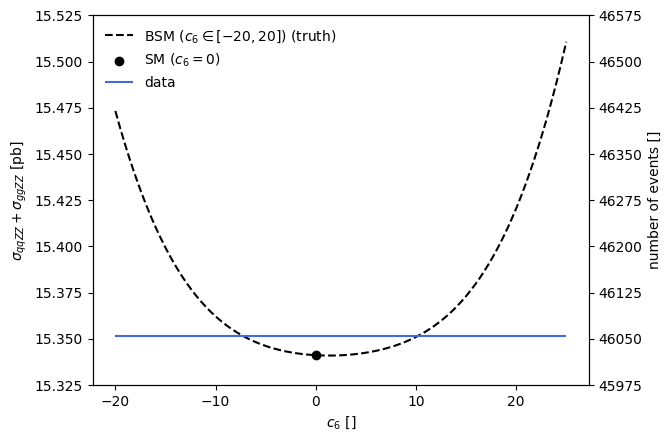

In [ ]:
plt.plot(c6_values, full_BSM_xs, color='black', linestyle='--', zorder=1, label='BSM ($c_6 \in [-20,20]$) (truth)')
#plt.plot(c6_values, sigma_ggZZ*np.sum(f(c6_values, coeffs_pred_ggZZ), axis=1)/GGZZ_INF_SIZE + sigma_qqZZ, color='royalblue', zorder=1, label='BSM ($c_6 \in [-20,20]$) (ROLYPOLY)')
plt.scatter(0, full_SM_xs, color='k', marker='o', zorder=2, label='SM ($c_6=0$)')
plt.hlines(sigma_data, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], color='royalblue', linestyle='-', label='data')

ax1 = plt.gca()
ax1.set_ylim(ax1.get_yticks()[0],ax1.get_yticks()[-1])
#ax1.set_ylabel('$\sigma_{qqZZ} + \sigma_{ggZZ}$ [pb]')
ax1.set_ylabel('$total cross section$ [pb]')

ax2 = ax1.twinx()

y_ticks_number = np.array(ax1.get_yticks())*luminosity

ax2.set_yticks(y_ticks_number)
ax2.set_ylim(y_ticks_number[0], y_ticks_number[-1])
ax2.set_ylabel('number of events []')

ax1.legend(frameon=False)
ax1.set_xlabel('$c_6$ []')

plt.show()

In [859]:
print(f'XS minimum at c6={c6_values[np.argmin(sigma_ggZZ_BSM)]:0.2f}')

XS minimum at c6=1.33


In [ ]:
N_data = sigma_data*luminosity

# Poisson term
t_1 = - 2 * N_data * (np.log(nu) - np.log(nu_SM)) + 2 * (nu - nu_SM) 

In [ ]:
# Used for ggZZ only
t_2 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] * np.log(sigma_ggZZ/sigma_ggZZ_BSM[:,np.newaxis] * f(c6_values, coeffs_pred)), axis=1)

In [ ]:
#p_ratio = full_SM_xs/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)/(1 + sigma_qqZZ/sigma_ggZZ * r)

In [ ]:
# Used for ggZZ + qqZZ
p_ratio = sigma_ggZZ/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred) + sigma_qqZZ/sigma_ggZZ*r)

t_3 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:] * np.log(p_ratio), axis=1)

In [ ]:
t = t_1 + t_3

In [865]:
t_min = c6_values[np.argmin(t)]

In [ ]:
# Print top ten lowest values
print(c6_values[np.argsort(t)[:10]])
print(t[np.argsort(t)[:10]])

[21.76  21.715 21.805 21.67  21.85  21.625 21.895 21.58  21.94  21.535]
[-6.16401759 -6.16392502 -6.16362597 -6.16335587 -6.16274244 -6.1623177
 -6.16135921 -6.16081797 -6.15946842 -6.15886406]


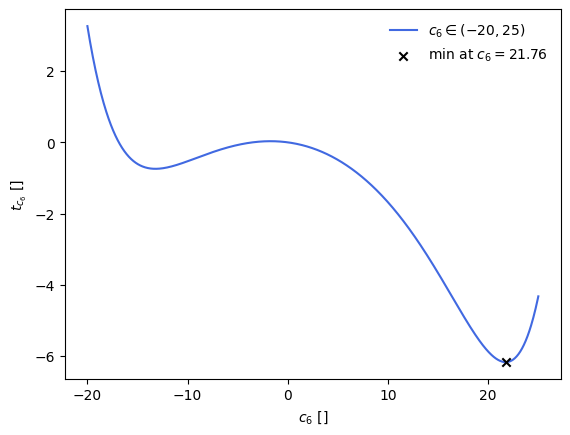

In [867]:
plt.plot(c6_values, t, color='royalblue', zorder=1, label=f'$c_6 \in {C6_LINSPACE[0],C6_LINSPACE[1]}$')
plt.scatter(t_min, np.min(t), marker='x', color='k', label=f'min at $c_6 = {t_min:0.2f}$')


plt.ylabel('$t_{c_6}$ []')

plt.legend(frameon=False)
plt.xlabel('$c_6$ []')


plt.show()

In [835]:
ci = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+1)))[:2]], 2))

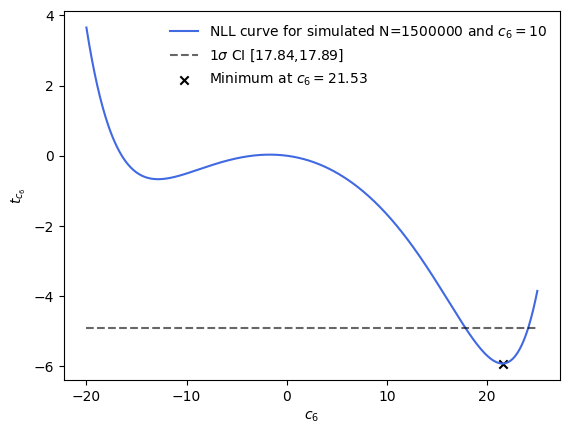

In [836]:
plt.plot(c6_values, t, color='royalblue', label=f'NLL curve for simulated N={SAMPLE_SIZE} and $c_6 = {C6_VAL_DATA}$')
plt.hlines(np.min(t)+1, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='k', alpha=0.6, label=f'$1\sigma$ CI [{ci[0]},{ci[1]}]')
plt.scatter(t_min, np.min(t), color='k', marker='x', label=f'Minimum at $c_6 = {round(t_min,2)}$')

plt.xlabel('$c_6$')
plt.ylabel('$t_{c_6}$')

plt.legend(frameon=False)
plt.show()